<a href="https://colab.research.google.com/github/JBorean11/EMSC2010-W10-L1/blob/main/EMSC2010_W10_L1_NB4_u7926254.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB4

Use this notebook to process the Japanese cherry blossoms data and see if you can find a pattern in the long term data.

The excel data file ```blossom_doy.xlsx``` contains two variables:


1.   ```year```: The year of the cherry bloom.
2.   ```doy```: The day of the year of the first cherry bloom (where day 0 corresponds to January 1)

Don't forget to use the code in ```EMSC2010-W10-L1-NB2``` and ```EMSC2010-W10-L1-NB3``` as a template for this problem.



In [1]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

In [5]:
df = pd.read_excel('blossom_doy.xlsx')
df.head()

,year,doy
0,812,92
1,815,105
2,831,96
3,851,108
4,853,104


Text(0, 0.5, 'Day of Year')

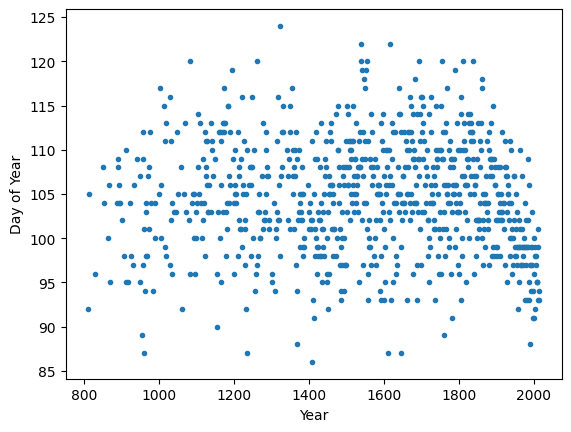

In [9]:
plt.plot(df['year'], df['doy'], '.')
plt.xlabel('Year')
plt.ylabel('Day of Year')

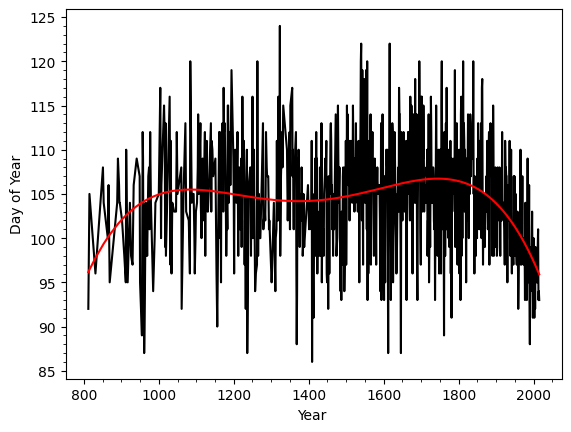

In [31]:
order = 4
 #set the polynomial order
pp = np.polyfit(df['year'],df['doy'],order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,df['year']) #find the value of the polynomial at each time point.

plt.plot(df['year'],df['doy'],'k') #plot the data
plt.plot(df['year'],trend,'r') #plot the trend
plt.xlabel('Year ') #label the x-axis
plt.ylabel('Day of Year') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

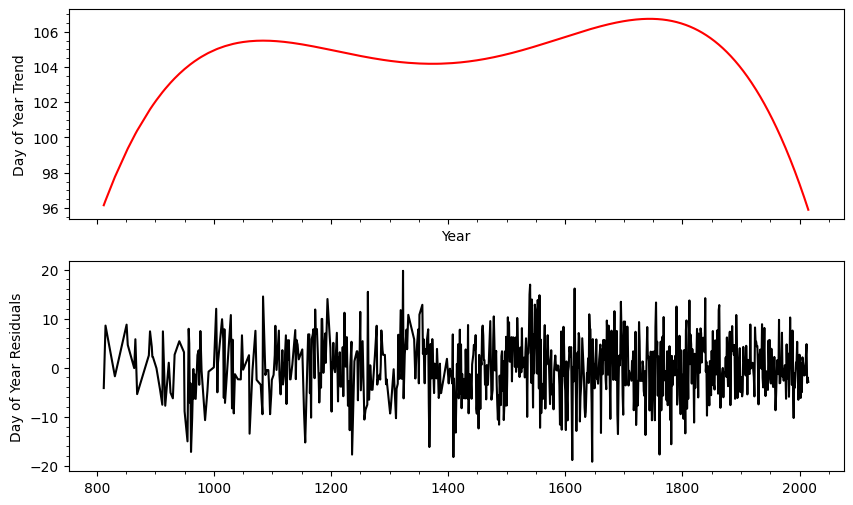

In [33]:
residuals = df['doy']-trend #find the residuals
fig, axes = plt.subplots(2,1, figsize=(10, 6), sharex = True) #make 2 subplots with the same x-axis

axes[0].plot(df['year'],trend,'r') #plot the polynomial trend
axes[1].plot(df['year'],residuals,'k') #plot the residuals

axes[0].set_xlabel('Year') #label the x-axis
axes[0].set_ylabel('Day of Year Trend') #label the trend y-axis
axes[1].set_ylabel('Day of Year Residuals') #label the residual y-axis

axes[0].minorticks_on() #add minorticks
axes[1].minorticks_on() #add minorticks

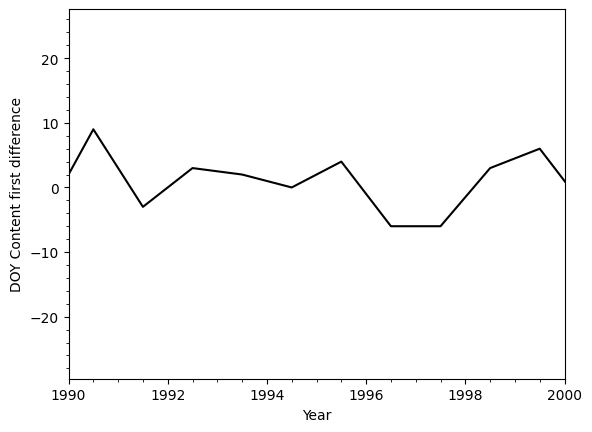

In [40]:
doy_diff = np.diff(df['doy']) #difference between neighboring points
year_diff = (df['year'].values[:-1] + df['year'].values[1:])/2 #find the mid-point in time between points (needed for plotting)
plt.plot(year_diff,doy_diff,'k') #plot the differences
plt.xlim([1990,2000]) #zoom in to see the details

plt.xlabel('Year') #label the x-axis
plt.ylabel('DOY Content first difference') #label the y-axis
plt.minorticks_on() #add minorticks

In [16]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [29]:
w = 31 #length of the moving average
ys = moving_average(df['doy'], w) #process the signal
ts = moving_average(df['year'], w) #process the times

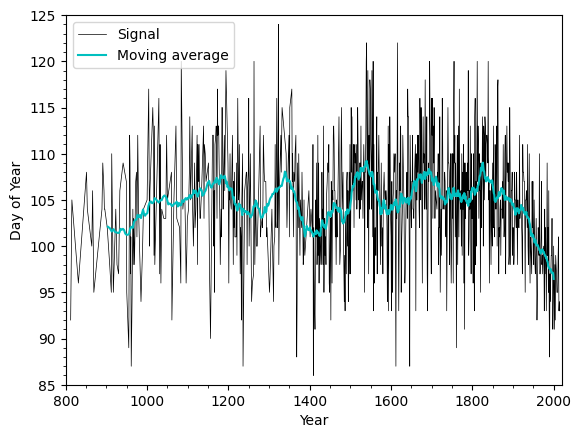

In [30]:
plt.plot(df['year'],df['doy'],'k',linewidth=0.5,label='Signal') #plot the noisy signal
plt.plot(ts,ys,'c',label='Moving average') #plot the moving average
plt.xlim([800,2020]) #limit the x-axis
plt.ylim([85,125]) #limit the y-axis
plt.xlabel('Year') #label the x-axis
plt.ylabel('Day of Year') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks